<a href="https://colab.research.google.com/github/OJB-Quantum/Spintronics-Generative-Layouts/blob/main/Fibonacci_Word_MTJ_Electrode_Array_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Fibonacci Word Fractal MTJ Electrode Array

This notebook generates a hierarchical 4 × 4 array of 3.5 µm-wide Fibonacci-word-fractal electrodes. A 100 nm MTJ pillar is placed near every detected bend by default. The layout exports as OASIS or GDSII and renders full-array, unit-cell, and bend-detail previews directly in the notebook.


In [1]:
# Install the required layout and export libraries.
!python -m pip install -q uv
!uv pip install --system -q phidl gdstk ezdxf gdspy || python -m pip install -q phidl gdstk ezdxf gdspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 43.1 MB/s eta 0:00:00


Exported layout: /content/Fibonacci_Word_MTJ_Electrode_Array_4x4_n12.oas
Fibonacci order n: 12
Fibonacci word length / electrode segments: 377
Detected bends per unit cell: 232
MTJ pillars per unit cell: 232
Total MTJ pillars in array: 3712
Electrode width: 3.500 um
Pillar diameter: 100.000 nm
Unit-cell size: 341.500 um x 237.500 um
Array pitch: 343.000 um x 239.090 um
Database grid: 0.0020 nm


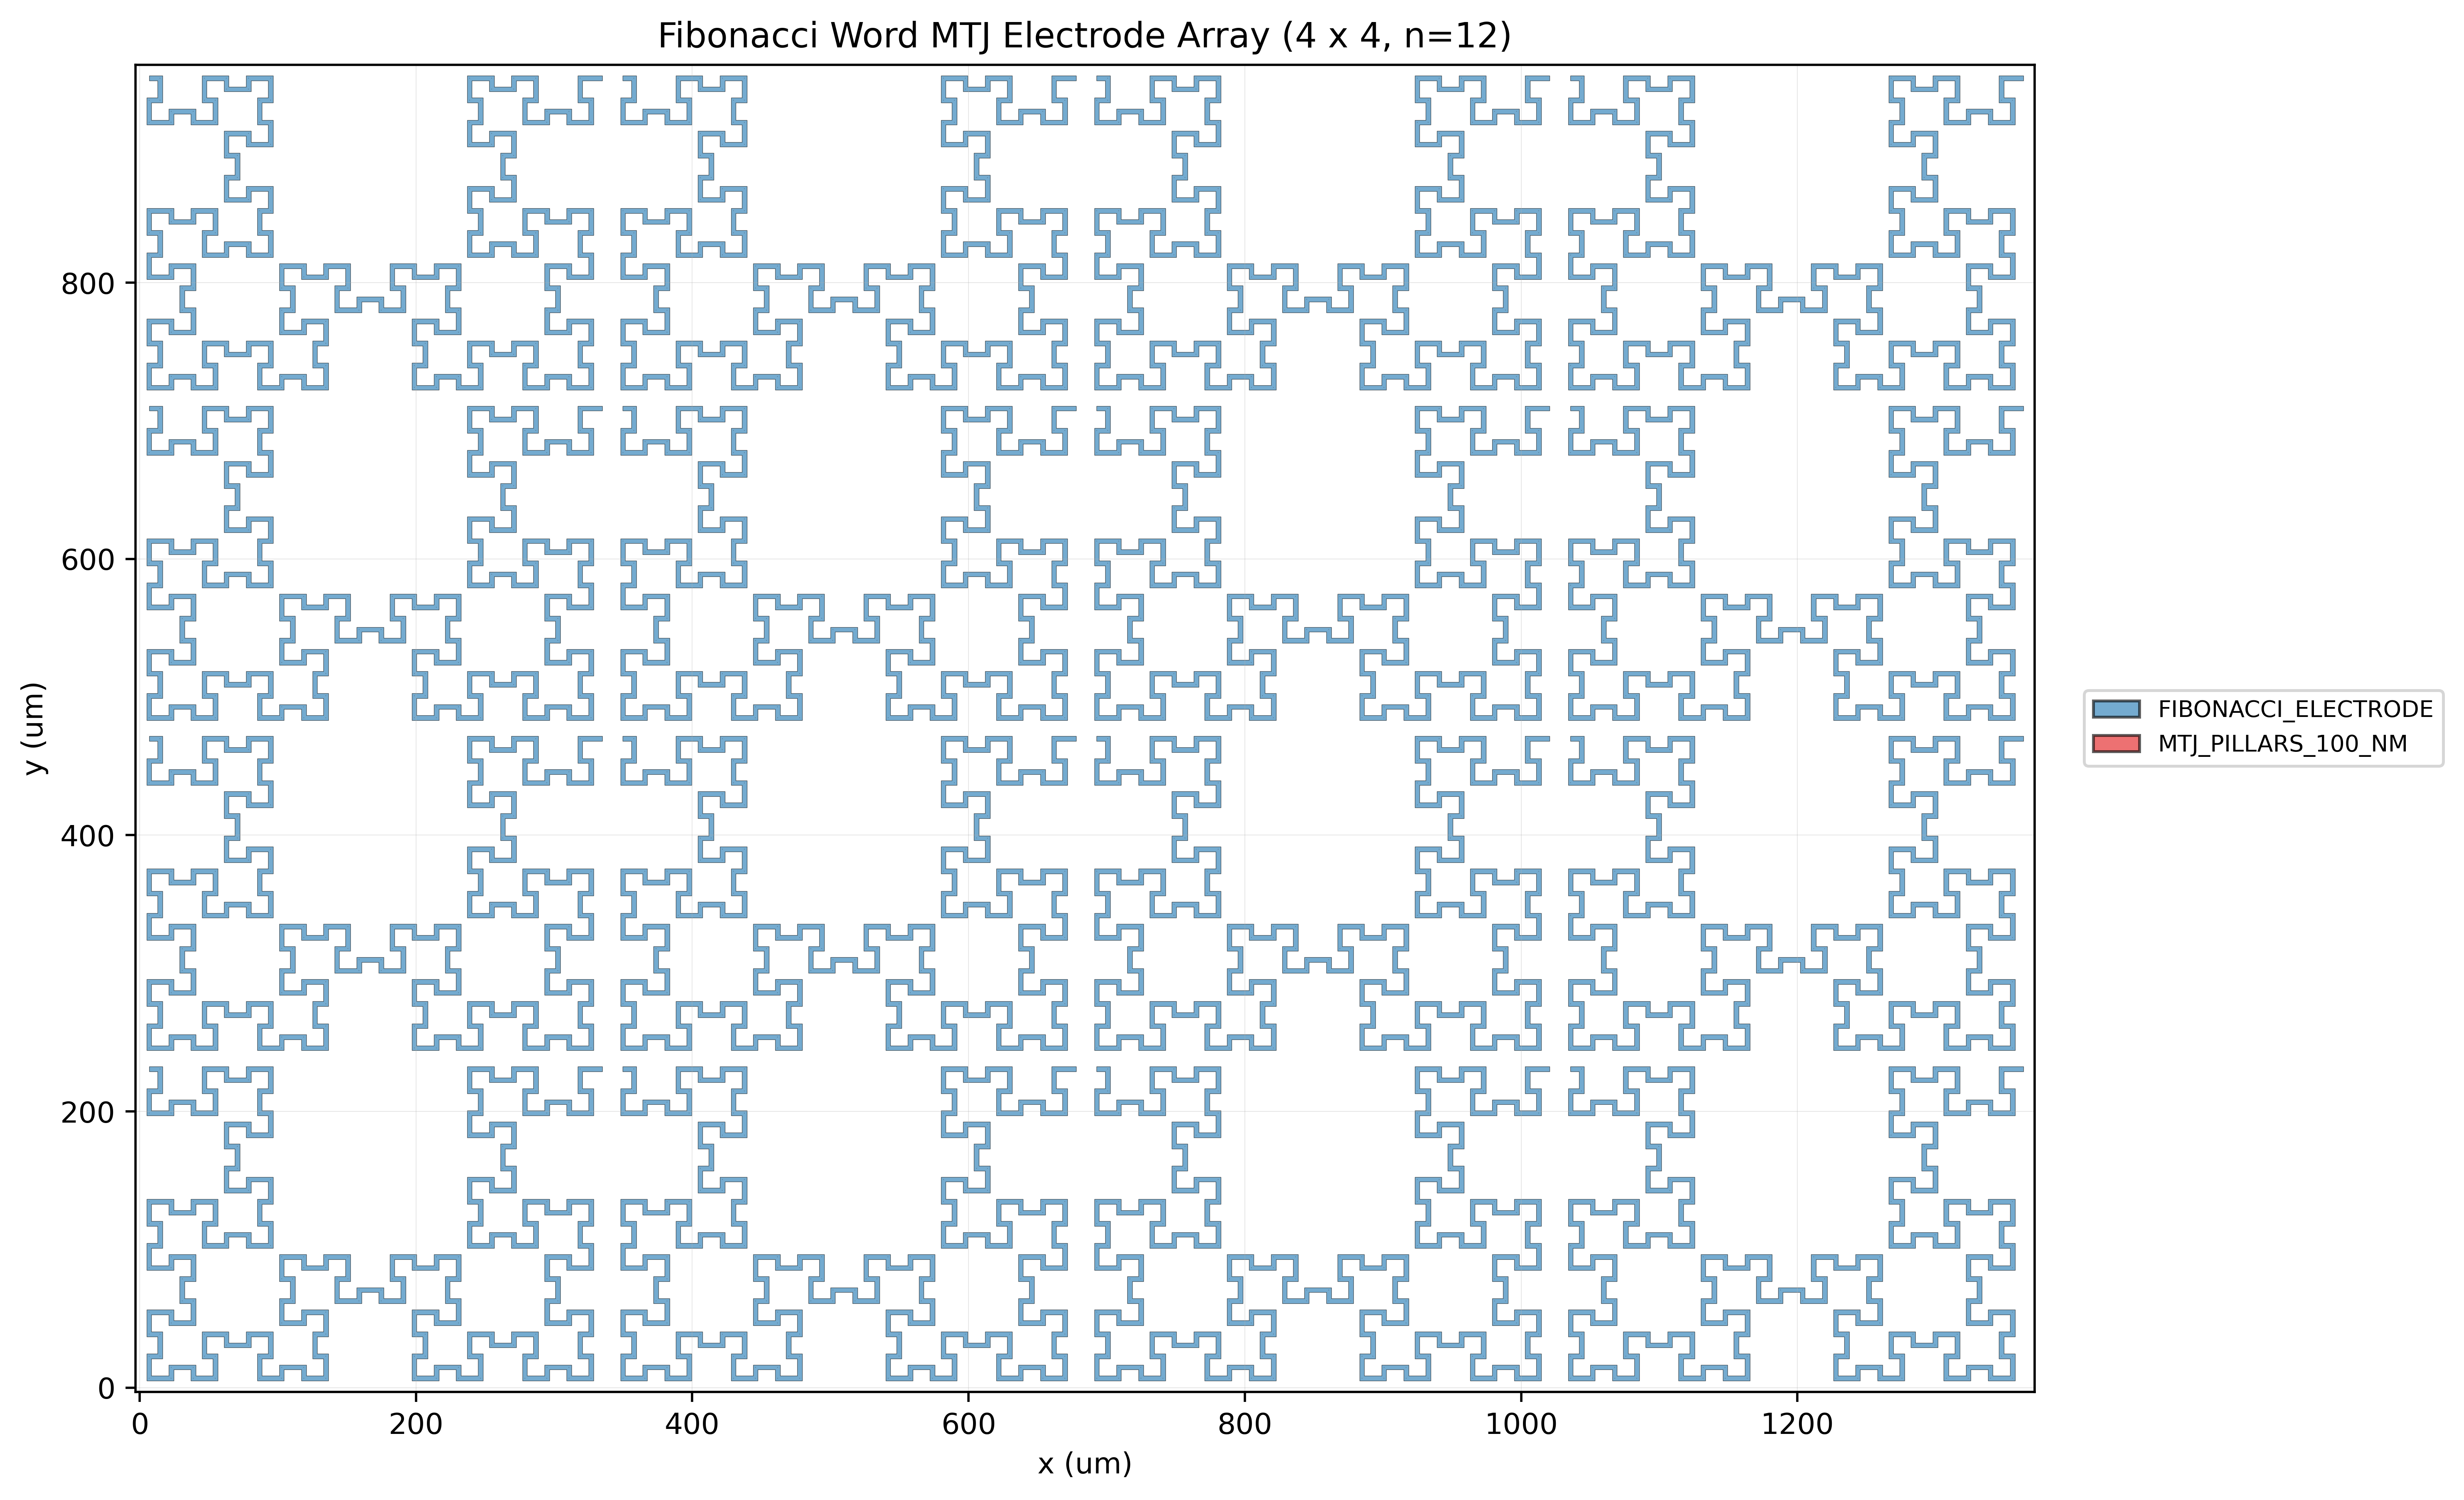

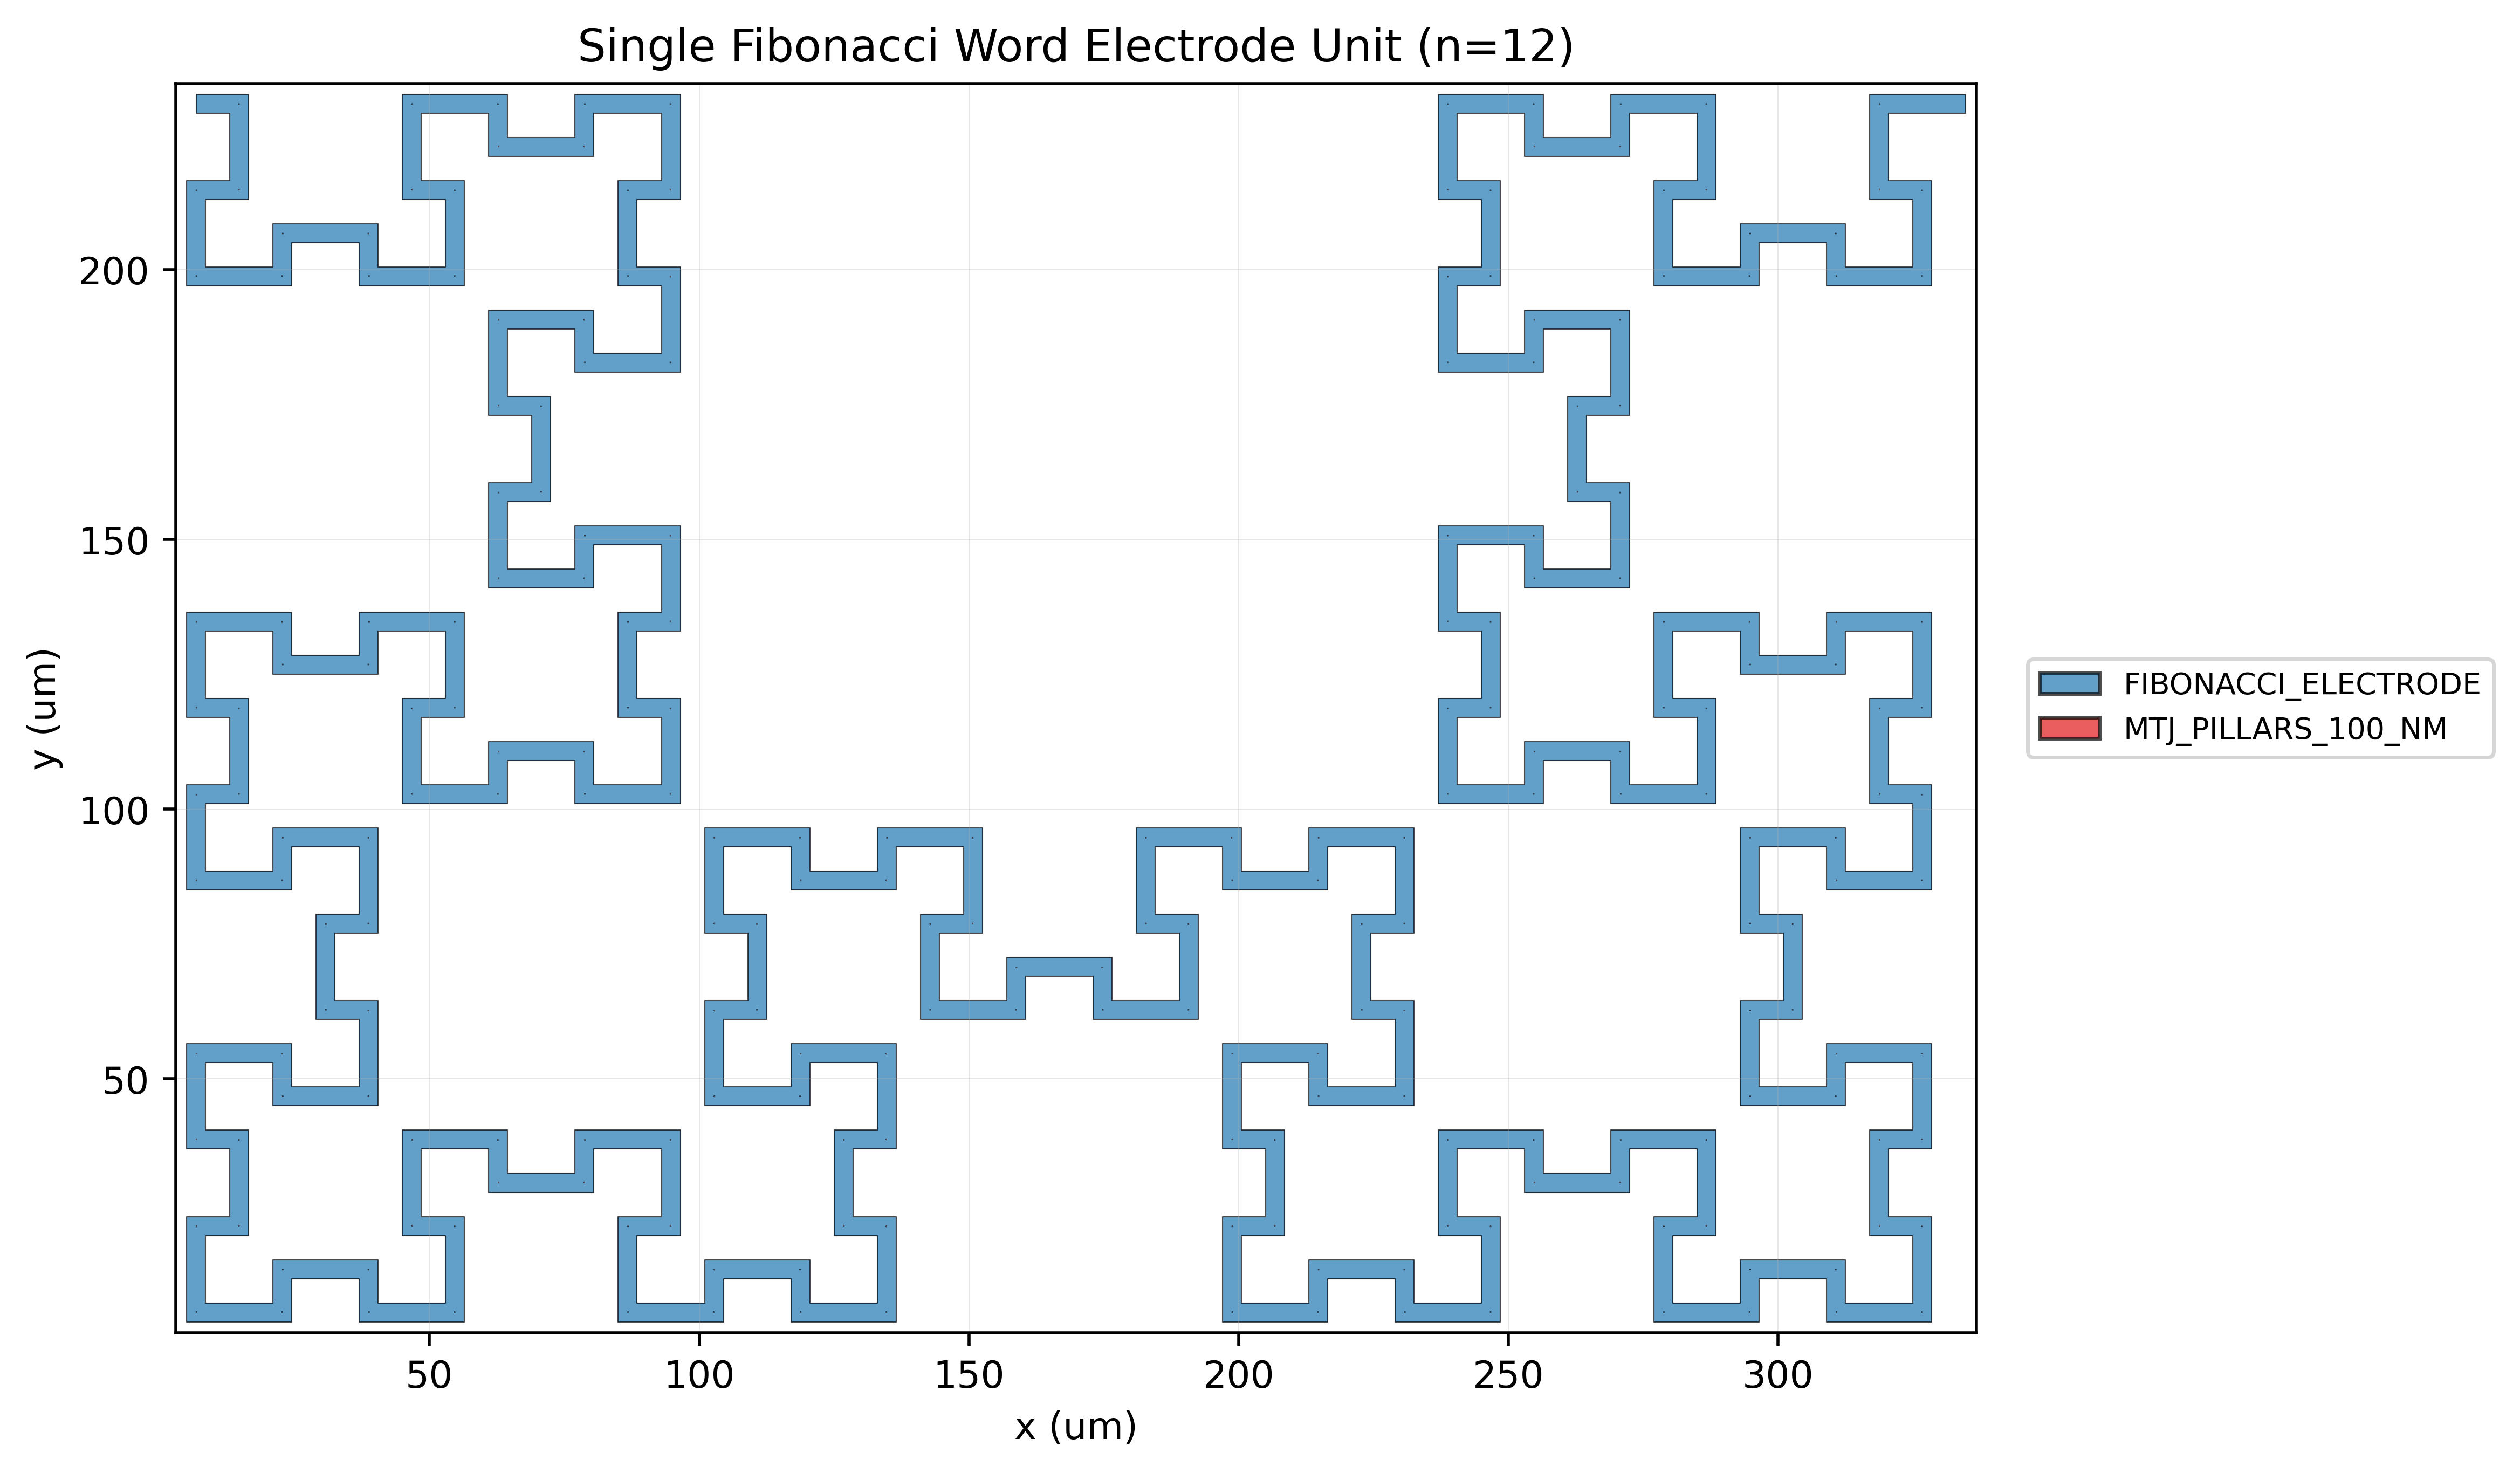

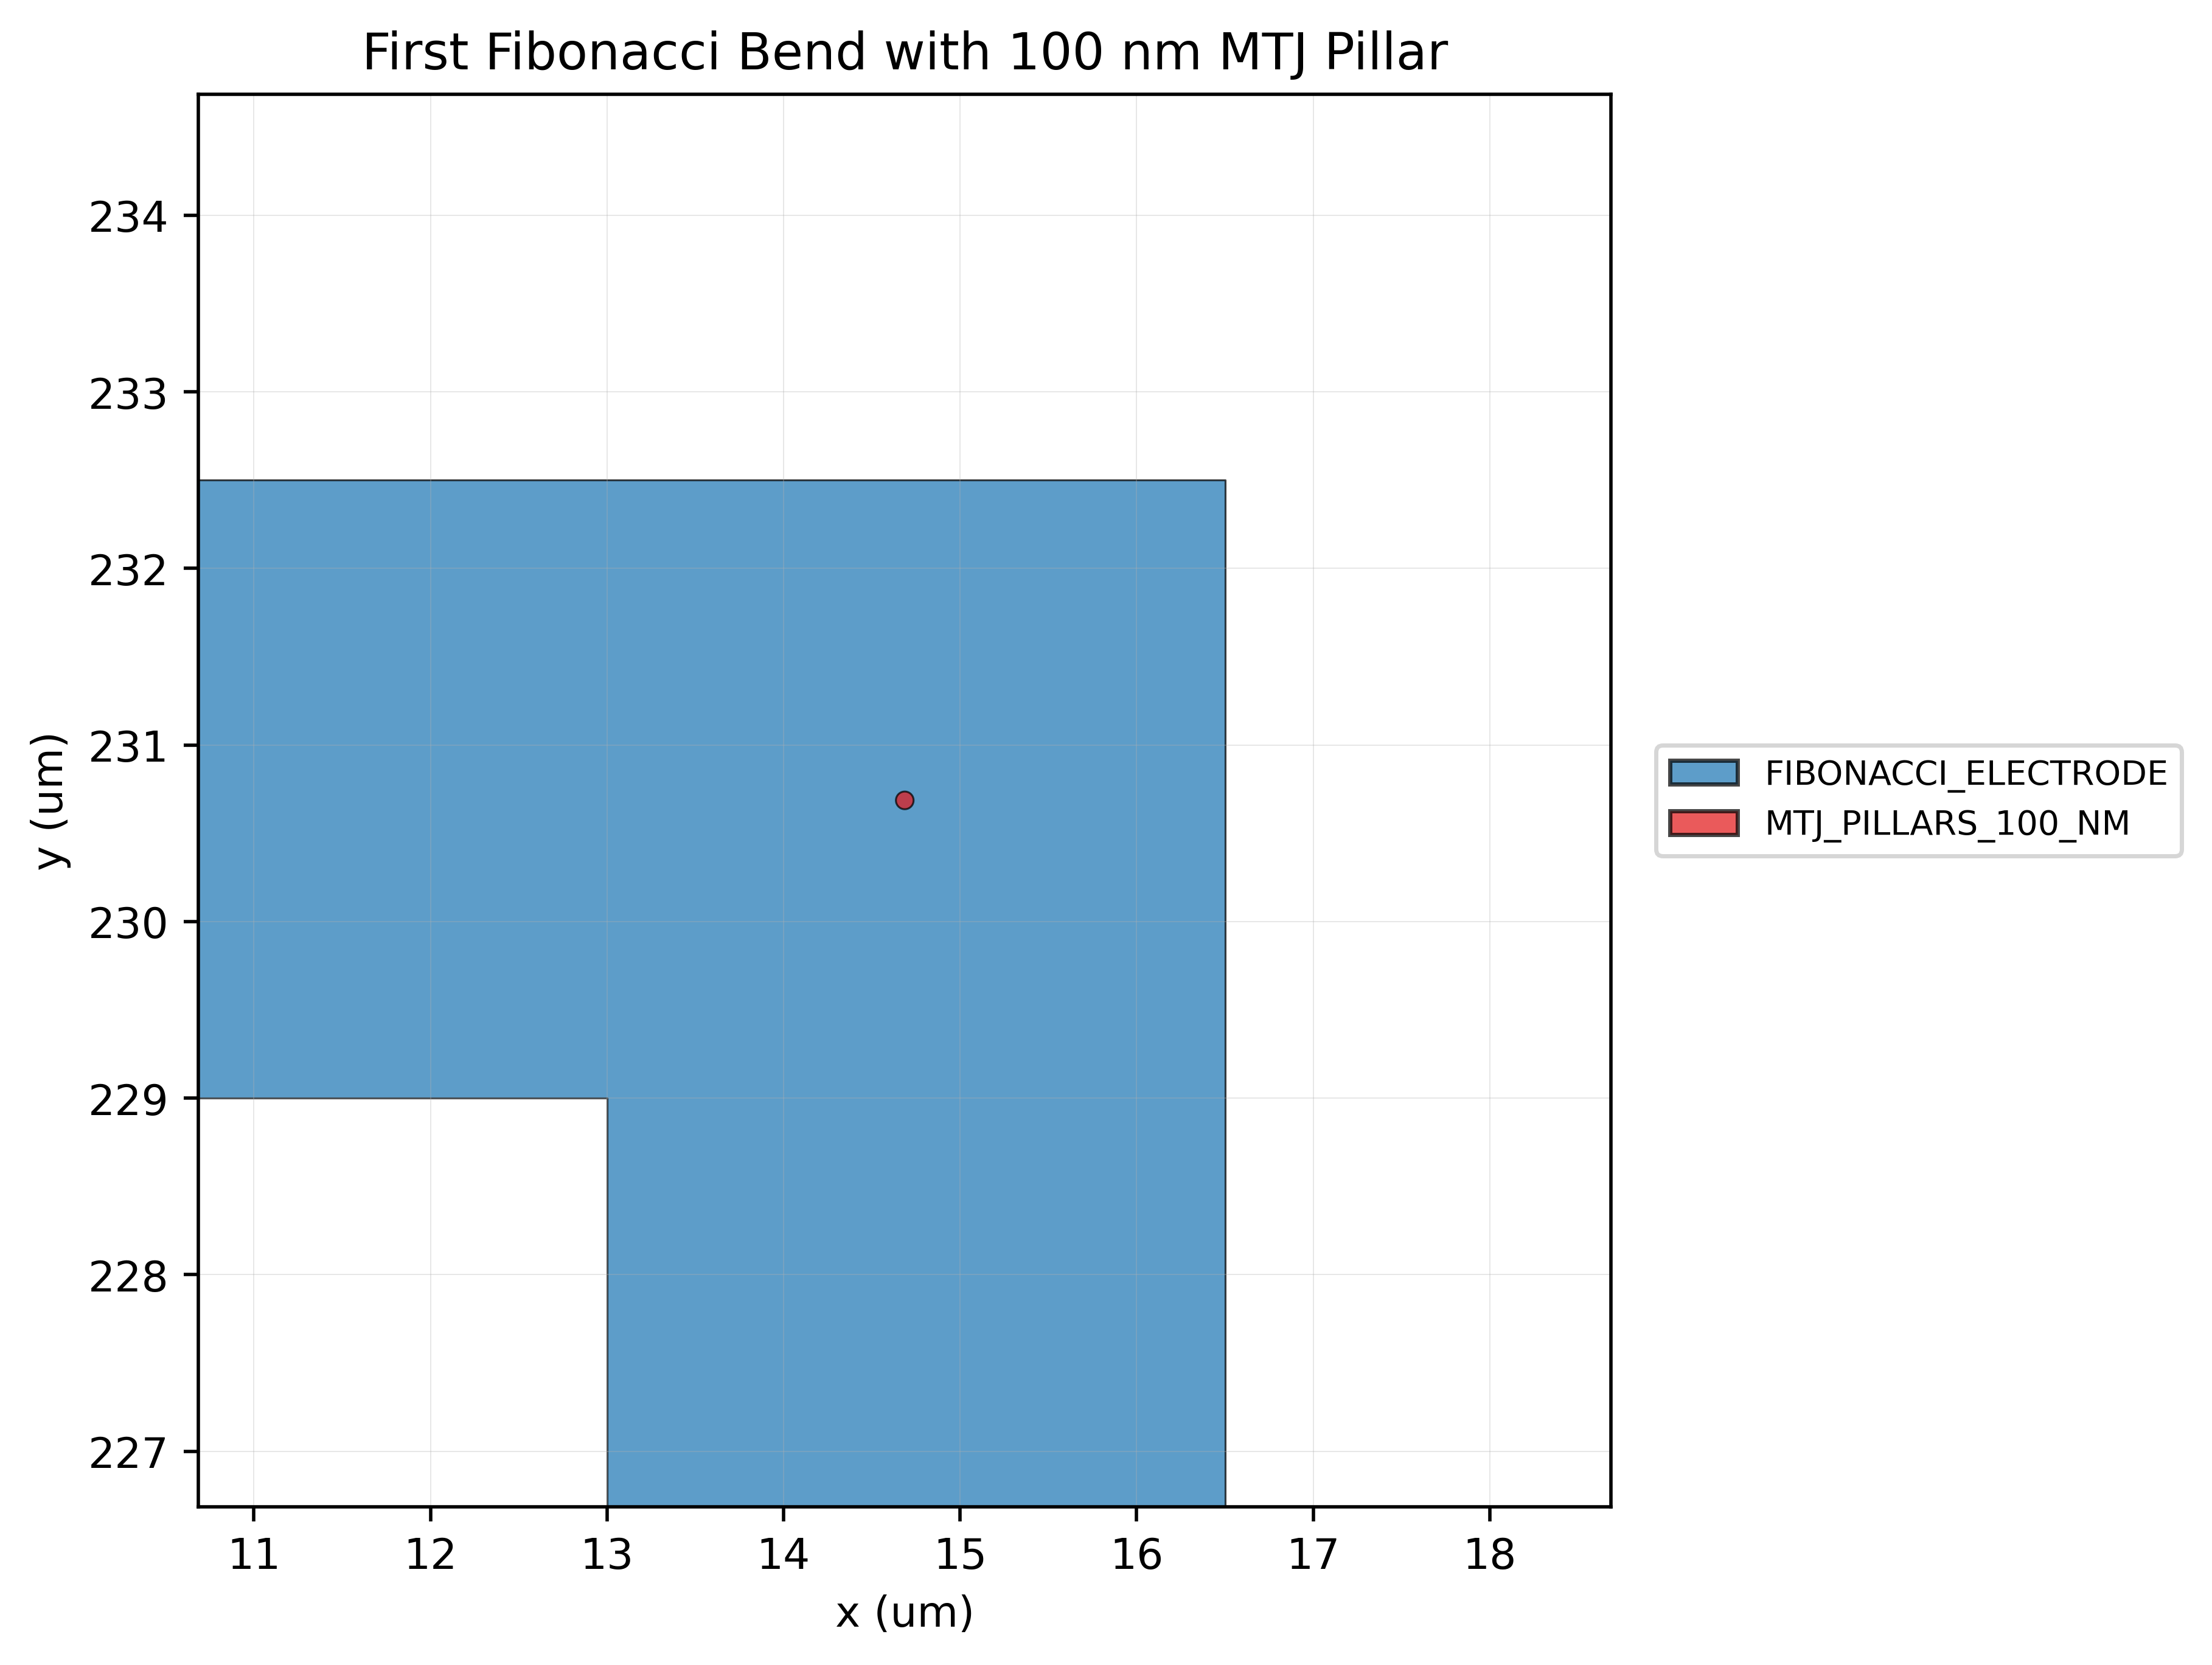

In [2]:
"""Generate Fibonacci-word-fractal electrodes with MTJ pillars.

The layout uses the canonical Fibonacci word recurrence

    F_0 = "0"
    F_1 = "01"
    F_n = F_(n - 1) + F_(n - 2)

and the odd-even drawing rule. Every symbol draws one forward segment. A
zero at an even one-based position turns left by 90 degrees, and a zero at
an odd one-based position turns right by 90 degrees. Setting
``MIRROR_FRACTAL`` reverses both turns.

GDSTK constructs the finite-width electrode path. PHIDL stores the unit-cell
geometry, builds the hierarchical array, renders previews, and writes the GDS
bridge used for optional OASIS export.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Final, Literal

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch, Rectangle
from phidl import Device

###############################################################
# Control knobs
###############################################################
OUTPUT_BASENAME: Final[str] = "Fibonacci_Word_MTJ_Electrode_Array_4x4_n12"
OUTPUT_FORMAT: Final[Literal["gds", "oas"]] = "oas"
OUTPUT_DIRECTORY: Final[Path] = Path.cwd()

# Fibonacci-word-fractal geometry
FIBONACCI_ITERATIONS: Final[int] = 12
SEGMENT_LENGTH_UM: Final[float] = 8.000
TURN_ANGLE_DEG: Final[float] = 90.0
MIRROR_FRACTAL: Final[bool] = False

# Electrode geometry. This preserves the 3.5 um bend width from the reference.
ELECTRODE_WIDTH_UM: Final[float] = 3.500
CELL_MARGIN_UM: Final[float] = 5.000
PATH_TOLERANCE_UM: Final[float] = 1.0e-3

# MTJ geometry and placement
PILLAR_DIAMETER_NM: Final[float] = 100.0
PILLAR_CIRCLE_POINTS: Final[int] = 256
PILLAR_EVERY_NTH_BEND: Final[int] = 1
PILLAR_CORNER_BISECTOR_OFFSET_UM: Final[float] = 0.090
ENABLE_PILLAR_DATABASE_GRID_SNAP: Final[bool] = True

# XY array controls
ARRAY_SIZE_X: Final[int] = 4
ARRAY_SIZE_Y: Final[int] = 4
ELECTRODE_EDGE_GAP_X_UM: Final[float] = 1.50
ELECTRODE_EDGE_GAP_Y_UM: Final[float] = 1.59

# GDSII and OASIS database controls
GDS_UNIT_M: Final[float] = 1e-6
GDS_PRECISION_M: Final[float] = 2e-12
GDS_INTEGER_COORDINATE_LIMIT: Final[int] = 2_000_000_000
OAS_CIRCLE_TOLERANCE_UM: Final[float] = 5.0e-5

# Notebook display controls
DISPLAY_AFTER_BUILD: Final[bool] = True
DISPLAY_SINGLE_UNIT_ZOOM: Final[bool] = True
DISPLAY_FIRST_BEND_DETAIL: Final[bool] = True
DOWNLOAD_AFTER_EXPORT_IN_COLAB: Final[bool] = False

PREVIEW_DPI: Final[int] = 500
PREVIEW_FIGSIZE_IN: Final[tuple[float, float]] = (12.0, 9.0)
PREVIEW_PADDING_UM: Final[float] = 8.0
PREVIEW_EDGE_LINEWIDTH: Final[float] = 0.18
PREVIEW_ALPHA: Final[float] = 0.62

UNIT_ZOOM_FIGSIZE_IN: Final[tuple[float, float]] = (9.0, 7.0)
UNIT_ZOOM_DPI: Final[int] = 500
BEND_DETAIL_HALF_WINDOW_UM: Final[float] = 4.0
BEND_DETAIL_FIGSIZE_IN: Final[tuple[float, float]] = (6.5, 6.5)

SHOW_CELL_BOUNDARY_IN_PREVIEW: Final[bool] = True
# Optional debug center marks. These are disabled by default so
# each MTJ location is rendered as one physical circle.
SHOW_PILLAR_CENTER_MARKERS: Final[bool] = False
PILLAR_MARKER_SIZE_PT: Final[float] = 10.0

DATABASE_GRID_UM: Final[float] = GDS_PRECISION_M / GDS_UNIT_M
DATABASE_GRID_NM: Final[float] = DATABASE_GRID_UM * 1e3

mpl.rcParams["figure.dpi"] = PREVIEW_DPI
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"


Coordinate = tuple[float, float]
Polygon = list[Coordinate]


@dataclass(frozen=True)
class LayerSpec:
    """Describe one exported and previewed layout layer.

    Attributes:
        name: Human-readable layer name.
        layer: GDSII layer number.
        datatype: GDSII datatype number.
        color: Matplotlib preview color.
    """

    name: str
    layer: int
    datatype: int
    color: str


@dataclass(frozen=True)
class BoundingBox:
    """Store an axis-aligned bounding box in micrometers."""

    xmin: float
    ymin: float
    xmax: float
    ymax: float

    @property
    def width(self) -> float:
        """Return the bounding-box width."""
        return self.xmax - self.xmin

    @property
    def height(self) -> float:
        """Return the bounding-box height."""
        return self.ymax - self.ymin


@dataclass(frozen=True)
class BendCorner:
    """Store one centerline bend and its adjacent unit directions."""

    center: Coordinate
    incoming_direction: Coordinate
    outgoing_direction: Coordinate


@dataclass(frozen=True)
class UnitGeometry:
    """Store generated centerline, pillar, and cell geometry."""

    fibonacci_word: str
    centerline_points: tuple[Coordinate, ...]
    bend_corners: tuple[BendCorner, ...]
    pillar_centers: tuple[Coordinate, ...]
    bounds: BoundingBox


LAYERS: Final[dict[str, LayerSpec]] = {
    "FIBONACCI_ELECTRODE": LayerSpec(
        "FIBONACCI_ELECTRODE",
        2,
        0,
        "#1f78b4",
    ),
    "MTJ_PILLARS": LayerSpec(
        "MTJ_PILLARS_100_NM",
        3,
        0,
        "#e31a1c",
    ),
}


def validate_control_knobs() -> None:
    """Validate user-adjustable geometry and database controls."""
    if FIBONACCI_ITERATIONS < 1:
        raise ValueError("FIBONACCI_ITERATIONS must be at least 1.")
    if SEGMENT_LENGTH_UM <= 0.0:
        raise ValueError("SEGMENT_LENGTH_UM must be positive.")
    if not 0.0 < TURN_ANGLE_DEG < 180.0:
        raise ValueError("TURN_ANGLE_DEG must lie between 0 and 180 degrees.")
    if ELECTRODE_WIDTH_UM <= 0.0:
        raise ValueError("ELECTRODE_WIDTH_UM must be positive.")
    if SEGMENT_LENGTH_UM <= ELECTRODE_WIDTH_UM:
        raise ValueError(
            "SEGMENT_LENGTH_UM must exceed ELECTRODE_WIDTH_UM so adjacent "
            "bends remain geometrically distinct."
        )
    if PILLAR_DIAMETER_NM <= 0.0:
        raise ValueError("PILLAR_DIAMETER_NM must be positive.")
    if PILLAR_CIRCLE_POINTS < 32:
        raise ValueError("PILLAR_CIRCLE_POINTS must be at least 32.")
    if PILLAR_EVERY_NTH_BEND < 1:
        raise ValueError("PILLAR_EVERY_NTH_BEND must be at least 1.")
    if ARRAY_SIZE_X < 1 or ARRAY_SIZE_Y < 1:
        raise ValueError("ARRAY_SIZE_X and ARRAY_SIZE_Y must be at least 1.")
    if CELL_MARGIN_UM < 0.0:
        raise ValueError("CELL_MARGIN_UM must be nonnegative.")
    if GDS_PRECISION_M <= 0.0 or GDS_UNIT_M <= 0.0:
        raise ValueError("GDS unit and precision values must be positive.")

    pillar_radius_um = 0.5 * PILLAR_DIAMETER_NM * 1e-3
    available_half_width_um = 0.5 * ELECTRODE_WIDTH_UM
    maximum_offset_um = available_half_width_um - pillar_radius_um
    if PILLAR_CORNER_BISECTOR_OFFSET_UM < 0.0:
        raise ValueError(
            "PILLAR_CORNER_BISECTOR_OFFSET_UM must be nonnegative."
        )
    if PILLAR_CORNER_BISECTOR_OFFSET_UM > maximum_offset_um:
        raise ValueError(
            "The pillar corner offset moves the pillar beyond the electrode "
            "half-width. Reduce PILLAR_CORNER_BISECTOR_OFFSET_UM."
        )


def fibonacci_word(iterations: int) -> str:
    """Return the Fibonacci word F_n.

    Args:
        iterations: Fibonacci word index ``n`` with ``F_0 = '0'`` and
            ``F_1 = '01'``.

    Returns:
        Fibonacci word at the requested index.
    """
    if iterations == 0:
        return "0"
    if iterations == 1:
        return "01"

    previous_previous = "0"
    previous = "01"
    for _ in range(2, iterations + 1):
        current = previous + previous_previous
        previous_previous = previous
        previous = current

    return previous


def rotate_direction(
    direction: np.ndarray,
    turn_sign: int,
) -> np.ndarray:
    """Rotate a direction by the configured signed turn angle.

    Args:
        direction: Two-component unit vector.
        turn_sign: ``+1`` for left and ``-1`` for right.

    Returns:
        Rotated unit vector.
    """
    if turn_sign not in {-1, 1}:
        raise ValueError("turn_sign must be +1 or -1.")

    angle_rad = np.deg2rad(turn_sign * TURN_ANGLE_DEG)
    rotation_matrix = np.array(
        [
            [np.cos(angle_rad), -np.sin(angle_rad)],
            [np.sin(angle_rad), np.cos(angle_rad)],
        ],
        dtype=float,
    )
    return normalize_vector(rotation_matrix @ direction)


def build_raw_centerline(word: str, step_um: float) -> np.ndarray:
    """Apply the odd-even rule and return every segment endpoint.

    Args:
        word: Fibonacci word containing zero and one symbols.
        step_um: Centerline segment length in micrometers.

    Returns:
        Array with shape ``(len(word) + 1, 2)``.
    """
    position = np.array([0.0, 0.0], dtype=float)
    direction = np.array([1.0, 0.0], dtype=float)
    points = [position.copy()]
    mirror_sign = -1 if MIRROR_FRACTAL else 1

    for one_based_position, symbol in enumerate(word, start=1):
        position = position + step_um * direction
        points.append(position.copy())

        is_final_symbol = one_based_position == len(word)
        if symbol == "1" or is_final_symbol:
            continue

        if symbol != "0":
            raise ValueError(f"Unexpected Fibonacci word symbol: {symbol!r}")

        turn_sign = 1 if one_based_position % 2 == 0 else -1
        direction = rotate_direction(
            direction,
            mirror_sign * turn_sign,
        )

    return np.asarray(points, dtype=float)


def normalize_vector(vector: np.ndarray) -> np.ndarray:
    """Return a unit vector.

    Args:
        vector: Input vector.

    Returns:
        Unit vector with floating-point components.
    """
    norm = float(np.linalg.norm(vector))
    if norm <= 0.0:
        raise ValueError("A zero-length direction vector was generated.")
    return vector / norm


def find_bend_corners(raw_points: np.ndarray) -> list[BendCorner]:
    """Identify every true direction change in a centerline.

    Args:
        raw_points: Every segment endpoint from the turtle construction.

    Returns:
        Ordered bend metadata.
    """
    corners: list[BendCorner] = []

    for point_index in range(1, len(raw_points) - 1):
        incoming = normalize_vector(
            raw_points[point_index] - raw_points[point_index - 1]
        )
        outgoing = normalize_vector(
            raw_points[point_index + 1] - raw_points[point_index]
        )

        cross_z = incoming[0] * outgoing[1] - incoming[1] * outgoing[0]
        if np.isclose(cross_z, 0.0, atol=1e-12):
            continue

        corners.append(
            BendCorner(
                center=(
                    float(raw_points[point_index, 0]),
                    float(raw_points[point_index, 1]),
                ),
                incoming_direction=(float(incoming[0]), float(incoming[1])),
                outgoing_direction=(float(outgoing[0]), float(outgoing[1])),
            )
        )

    return corners


def simplify_centerline(raw_points: np.ndarray) -> np.ndarray:
    """Remove collinear interior points before GDSTK path generation.

    Args:
        raw_points: Every segment endpoint from the turtle construction.

    Returns:
        Centerline containing start, bends, and end.
    """
    if len(raw_points) <= 2:
        return raw_points.copy()

    kept_points = [raw_points[0]]
    for point_index in range(1, len(raw_points) - 1):
        previous_vector = raw_points[point_index] - raw_points[point_index - 1]
        next_vector = raw_points[point_index + 1] - raw_points[point_index]
        cross_z = (
            previous_vector[0] * next_vector[1]
            - previous_vector[1] * next_vector[0]
        )
        if np.isclose(cross_z, 0.0, atol=1e-12):
            continue
        kept_points.append(raw_points[point_index])

    kept_points.append(raw_points[-1])
    return np.asarray(kept_points, dtype=float)


def translate_corner(corner: BendCorner, shift: np.ndarray) -> BendCorner:
    """Translate one bend corner by a fixed vector."""
    center = np.asarray(corner.center, dtype=float) + shift
    return BendCorner(
        center=(float(center[0]), float(center[1])),
        incoming_direction=corner.incoming_direction,
        outgoing_direction=corner.outgoing_direction,
    )


def pillar_center_near_corner(
    corner: BendCorner,
    offset_um: float,
) -> Coordinate:
    """Place a pillar along the bend interior bisector.

    The bend point itself corresponds to the electrode centerline corner. A
    positive offset shifts the pillar toward the overlap of the incoming and
    outgoing trace arms, matching the near-corner placement style of the
    reference layout.

    Args:
        corner: Bend center and adjacent directions.
        offset_um: Shift along the interior arm-overlap bisector.

    Returns:
        Pillar center coordinate in micrometers.
    """
    incoming = np.asarray(corner.incoming_direction, dtype=float)
    outgoing = np.asarray(corner.outgoing_direction, dtype=float)
    overlap_bisector = normalize_vector(-incoming + outgoing)
    center = np.asarray(corner.center, dtype=float) + offset_um * overlap_bisector
    return float(center[0]), float(center[1])


def deduplicate_coordinates(
    coordinates: list[Coordinate],
    grid_um: float,
) -> list[Coordinate]:
    """Remove coordinate duplicates after grid quantization.

    Args:
        coordinates: Coordinates to deduplicate.
        grid_um: Quantization grid in micrometers.

    Returns:
        Ordered unique coordinates.
    """
    unique_coordinates: list[Coordinate] = []
    seen: set[tuple[int, int]] = set()

    for x_coord, y_coord in coordinates:
        key = (
            int(round(x_coord / grid_um)),
            int(round(y_coord / grid_um)),
        )
        if key in seen:
            continue
        seen.add(key)
        unique_coordinates.append((x_coord, y_coord))

    return unique_coordinates


def generate_unit_geometry() -> UnitGeometry:
    """Generate normalized centerline, corners, pillars, and cell bounds."""
    word = fibonacci_word(FIBONACCI_ITERATIONS)
    raw_points = build_raw_centerline(word, SEGMENT_LENGTH_UM)
    raw_corners = find_bend_corners(raw_points)
    simplified_points = simplify_centerline(raw_points)

    centerline_minimum = np.min(simplified_points, axis=0)
    centerline_maximum = np.max(simplified_points, axis=0)
    half_width_um = 0.5 * ELECTRODE_WIDTH_UM
    shift = np.array(
        [
            CELL_MARGIN_UM + half_width_um - centerline_minimum[0],
            CELL_MARGIN_UM + half_width_um - centerline_minimum[1],
        ],
        dtype=float,
    )

    translated_points = simplified_points + shift
    translated_corners = [translate_corner(corner, shift) for corner in raw_corners]

    selected_corners = translated_corners[::PILLAR_EVERY_NTH_BEND]
    pillar_centers = [
        pillar_center_near_corner(
            corner,
            PILLAR_CORNER_BISECTOR_OFFSET_UM,
        )
        for corner in selected_corners
    ]
    pillar_centers = deduplicate_coordinates(
        pillar_centers,
        max(DATABASE_GRID_UM, 1.0e-12),
    )

    centerline_span = centerline_maximum - centerline_minimum
    cell_width_um = (
        float(centerline_span[0]) + ELECTRODE_WIDTH_UM + 2.0 * CELL_MARGIN_UM
    )
    cell_height_um = (
        float(centerline_span[1]) + ELECTRODE_WIDTH_UM + 2.0 * CELL_MARGIN_UM
    )
    bounds = BoundingBox(0.0, 0.0, cell_width_um, cell_height_um)

    return UnitGeometry(
        fibonacci_word=word,
        centerline_points=tuple(
            (float(point[0]), float(point[1])) for point in translated_points
        ),
        bend_corners=tuple(translated_corners),
        pillar_centers=tuple(pillar_centers),
        bounds=bounds,
    )


def snap_value_to_grid(value_um: float, grid_um: float) -> float:
    """Return a coordinate snapped to a positive database grid."""
    if grid_um <= 0.0:
        raise ValueError("Database grid must be positive.")
    return round(value_um / grid_um) * grid_um


def remove_adjacent_duplicate_vertices(vertices: Polygon) -> Polygon:
    """Remove adjacent duplicates produced by database-grid snapping."""
    if len(vertices) == 0:
        return []

    pruned_vertices = [vertices[0]]
    for vertex in vertices[1:]:
        if vertex != pruned_vertices[-1]:
            pruned_vertices.append(vertex)

    if len(pruned_vertices) > 1 and pruned_vertices[0] == pruned_vertices[-1]:
        pruned_vertices.pop()

    return pruned_vertices


def circle_points(
    center_x: float,
    center_y: float,
    radius_um: float,
    number_of_points: int,
    snap_grid_um: float | None = None,
) -> Polygon:
    """Return a grid-compatible polygonal circle."""
    angles = np.linspace(0.0, 2.0 * np.pi, number_of_points, endpoint=False)
    vertices = [
        (
            center_x + radius_um * np.cos(angle),
            center_y + radius_um * np.sin(angle),
        )
        for angle in angles
    ]

    if snap_grid_um is None:
        return vertices

    snapped_vertices = [
        (
            snap_value_to_grid(x_coord, snap_grid_um),
            snap_value_to_grid(y_coord, snap_grid_um),
        )
        for x_coord, y_coord in vertices
    ]
    snapped_vertices = remove_adjacent_duplicate_vertices(snapped_vertices)

    if len(snapped_vertices) < 32:
        raise ValueError(
            "The database grid is too coarse for the selected pillar diameter."
        )

    return snapped_vertices


def validate_polygon_inside_bounds(
    polygon: Polygon,
    bounds: BoundingBox,
    tolerance_um: float = 1e-9,
) -> None:
    """Verify that every polygon vertex stays inside the unit-cell bounds."""
    for x_coord, y_coord in polygon:
        inside_x = bounds.xmin - tolerance_um <= x_coord <= bounds.xmax + tolerance_um
        inside_y = bounds.ymin - tolerance_um <= y_coord <= bounds.ymax + tolerance_um
        if inside_x and inside_y:
            continue
        raise ValueError(
            "Generated polygon leaves the unit-cell envelope at "
            f"({x_coord:.6f}, {y_coord:.6f}) um."
        )


def build_fibonacci_unit(geometry: UnitGeometry) -> Device:
    """Create one PHIDL unit cell containing the electrode and MTJs."""
    unit = Device(
        f"FIBONACCI_WORD_ELECTRODE_UNIT_N{FIBONACCI_ITERATIONS}"
    )

    electrode_path = gdstk.FlexPath(
        geometry.centerline_points,
        ELECTRODE_WIDTH_UM,
        joins="miter",
        ends="flush",
        tolerance=PATH_TOLERANCE_UM,
    )
    electrode_polygons = electrode_path.to_polygons()

    for electrode_polygon in electrode_polygons:
        polygon_points = [
            (float(x_coord), float(y_coord))
            for x_coord, y_coord in electrode_polygon.points
        ]
        validate_polygon_inside_bounds(polygon_points, geometry.bounds)
        unit.add_polygon(
            polygon_points,
            layer=(
                LAYERS["FIBONACCI_ELECTRODE"].layer,
                LAYERS["FIBONACCI_ELECTRODE"].datatype,
            ),
        )

    snap_grid_um = None
    if ENABLE_PILLAR_DATABASE_GRID_SNAP:
        snap_grid_um = DATABASE_GRID_UM

    pillar_radius_um = 0.5 * PILLAR_DIAMETER_NM * 1e-3
    for center_x, center_y in geometry.pillar_centers:
        pillar_polygon = circle_points(
            center_x=center_x,
            center_y=center_y,
            radius_um=pillar_radius_um,
            number_of_points=PILLAR_CIRCLE_POINTS,
            snap_grid_um=snap_grid_um,
        )
        validate_polygon_inside_bounds(pillar_polygon, geometry.bounds)
        unit.add_polygon(
            pillar_polygon,
            layer=(
                LAYERS["MTJ_PILLARS"].layer,
                LAYERS["MTJ_PILLARS"].datatype,
            ),
        )

    return unit


def build_xy_array(
    unit: Device,
    geometry: UnitGeometry,
) -> tuple[Device, float, float]:
    """Build the default hierarchical XY array."""
    pitch_x_um = geometry.bounds.width + ELECTRODE_EDGE_GAP_X_UM
    pitch_y_um = geometry.bounds.height + ELECTRODE_EDGE_GAP_Y_UM

    top = Device(
        f"FIBONACCI_WORD_ELECTRODE_ARRAY_{ARRAY_SIZE_X}X{ARRAY_SIZE_Y}"
    )
    for row_index in range(ARRAY_SIZE_Y):
        for column_index in range(ARRAY_SIZE_X):
            reference = top.add_ref(unit)
            reference.move(
                destination=(
                    column_index * pitch_x_um,
                    row_index * pitch_y_um,
                )
            )

    return top, pitch_x_um, pitch_y_um


def validate_device_database_range(
    device: Device,
    precision_m: float,
) -> None:
    """Verify that GDS integer coordinates fit the selected precision."""
    bounding_box = np.asarray(device.bbox, dtype=float)
    if bounding_box.size == 0:
        return

    maximum_coordinate_um = float(np.max(np.abs(bounding_box)))
    maximum_database_coordinate = (
        maximum_coordinate_um * GDS_UNIT_M / precision_m
    )
    if maximum_database_coordinate > GDS_INTEGER_COORDINATE_LIMIT:
        raise ValueError(
            "The selected GDS precision exceeds the signed integer coordinate "
            "range for this array extent. Increase GDS_PRECISION_M or reduce "
            "the array size."
        )


def export_layout(
    device: Device,
    output_directory: Path,
    basename: str,
    output_format: Literal["gds", "oas"],
) -> Path:
    """Export a PHIDL hierarchy as GDSII or OASIS."""
    validate_device_database_range(device, GDS_PRECISION_M)
    output_directory.mkdir(parents=True, exist_ok=True)
    output_path = output_directory / f"{basename}.{output_format}"

    if output_format == "gds":
        device.write_gds(
            str(output_path),
            unit=GDS_UNIT_M,
            precision=GDS_PRECISION_M,
            auto_rename=True,
        )
        return output_path

    if output_format == "oas":
        temporary_gds = output_directory / f"{basename}_temporary_bridge.gds"
        device.write_gds(
            str(temporary_gds),
            unit=GDS_UNIT_M,
            precision=GDS_PRECISION_M,
            auto_rename=True,
        )
        library = gdstk.read_gds(str(temporary_gds))

        try:
            library.unit = GDS_UNIT_M
            library.precision = GDS_PRECISION_M
        except AttributeError:
            pass

        try:
            library.write_oas(
                str(output_path),
                circle_tolerance=OAS_CIRCLE_TOLERANCE_UM,
            )
        except TypeError:
            library.write_oas(str(output_path))

        temporary_gds.unlink(missing_ok=True)
        return output_path

    raise ValueError("OUTPUT_FORMAT must be 'gds' or 'oas'.")


def get_layer_tuple(layer_key: int | tuple[int, int]) -> tuple[int, int]:
    """Normalize a PHIDL polygon layer key."""
    if isinstance(layer_key, tuple):
        return int(layer_key[0]), int(layer_key[1])
    return int(layer_key), 0


def render_cell_boundary(ax: plt.Axes, bounds: BoundingBox) -> None:
    """Draw a dashed unit-cell boundary in preview coordinates."""
    boundary = Rectangle(
        (bounds.xmin, bounds.ymin),
        bounds.width,
        bounds.height,
        fill=False,
        linewidth=0.8,
        linestyle="--",
    )
    ax.add_patch(boundary)


def render_sharp_preview(
    device: Device,
    geometry: UnitGeometry,
    title: str,
    figure_size: tuple[float, float],
    dpi: int,
    padding_um: float,
    linewidth: float,
    alpha: float,
    x_limits: tuple[float, float] | None = None,
    y_limits: tuple[float, float] | None = None,
    mark_unit_cell: bool = False,
    show_pillar_markers: bool = False,
) -> None:
    """Render a direct high-resolution Matplotlib preview.

    The exported pillar polygons are rendered directly. Optional
    center marks use plus signs so they cannot resemble a second
    circular pillar.
    """
    polygons_by_spec = device.get_polygons(by_spec=True)
    color_map = {
        (spec.layer, spec.datatype): spec.color for spec in LAYERS.values()
    }
    name_map = {
        (spec.layer, spec.datatype): spec.name for spec in LAYERS.values()
    }

    _, ax = plt.subplots(figsize=figure_size, dpi=dpi)
    all_vertices: list[np.ndarray] = []
    legend_handles: list[Patch] = []

    for layer_key, polygons in polygons_by_spec.items():
        layer_tuple = get_layer_tuple(layer_key)
        color = color_map.get(layer_tuple, "#808080")
        layer_name = name_map.get(layer_tuple, str(layer_tuple))
        polygon_arrays = [
            np.asarray(polygon, dtype=float)
            for polygon in polygons
            if len(polygon) >= 3
        ]
        if len(polygon_arrays) == 0:
            continue

        collection = PolyCollection(
            polygon_arrays,
            facecolors=color,
            edgecolors="black",
            linewidths=linewidth,
            alpha=alpha,
        )
        ax.add_collection(collection)
        all_vertices.extend(polygon_arrays)
        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor="black",
                label=layer_name,
                alpha=alpha,
            )
        )

    if len(all_vertices) > 0:
        stacked_vertices = np.vstack(all_vertices)
        xmin = float(np.min(stacked_vertices[:, 0]))
        xmax = float(np.max(stacked_vertices[:, 0]))
        ymin = float(np.min(stacked_vertices[:, 1]))
        ymax = float(np.max(stacked_vertices[:, 1]))

        ax.set_xlim(
            *(x_limits if x_limits is not None else (xmin - padding_um, xmax + padding_um))
        )
        ax.set_ylim(
            *(y_limits if y_limits is not None else (ymin - padding_um, ymax + padding_um))
        )

    if mark_unit_cell and SHOW_CELL_BOUNDARY_IN_PREVIEW:
        render_cell_boundary(ax, geometry.bounds)

    if show_pillar_markers and SHOW_PILLAR_CENTER_MARKERS:
        pillar_array = np.asarray(geometry.pillar_centers, dtype=float)
        if pillar_array.size > 0:
            ax.scatter(
                pillar_array[:, 0],
                pillar_array[:, 1],
                s=PILLAR_MARKER_SIZE_PT,
                marker="+",
                color="black",
                linewidths=0.45,
                label="MTJ pillar centers",
            )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    ax.set_title(title)
    ax.grid(True, linewidth=0.25, alpha=0.35)

    if len(legend_handles) > 0:
        ax.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
            fontsize=8,
        )

    plt.tight_layout()
    plt.subplots_adjust(right=0.82)
    plt.show()


def render_first_bend_detail(
    unit: Device,
    geometry: UnitGeometry,
) -> None:
    """Render a local view around the first MTJ-bearing bend.

    This view contains the physical 100 nm pillar polygon without
    an overlapping circular center marker.
    """
    if len(geometry.pillar_centers) == 0:
        return

    center_x, center_y = geometry.pillar_centers[0]
    half_window = BEND_DETAIL_HALF_WINDOW_UM
    render_sharp_preview(
        device=unit,
        geometry=geometry,
        title="First Fibonacci Bend with 100 nm MTJ Pillar",
        figure_size=BEND_DETAIL_FIGSIZE_IN,
        dpi=UNIT_ZOOM_DPI,
        padding_um=0.0,
        linewidth=0.45,
        alpha=0.72,
        x_limits=(center_x - half_window, center_x + half_window),
        y_limits=(center_y - half_window, center_y + half_window),
        mark_unit_cell=False,
        show_pillar_markers=False,
    )


def print_layout_summary(
    geometry: UnitGeometry,
    pitch_x_um: float,
    pitch_y_um: float,
    layout_path: Path,
) -> None:
    """Print key generated-layout metrics."""
    unit_pillar_count = len(geometry.pillar_centers)
    total_cell_count = ARRAY_SIZE_X * ARRAY_SIZE_Y
    total_pillar_count = unit_pillar_count * total_cell_count

    print(f"Exported layout: {layout_path}")
    print(f"Fibonacci order n: {FIBONACCI_ITERATIONS}")
    print(f"Fibonacci word length / electrode segments: {len(geometry.fibonacci_word)}")
    print(f"Detected bends per unit cell: {len(geometry.bend_corners)}")
    print(f"MTJ pillars per unit cell: {unit_pillar_count}")
    print(f"Total MTJ pillars in array: {total_pillar_count}")
    print(f"Electrode width: {ELECTRODE_WIDTH_UM:.3f} um")
    print(f"Pillar diameter: {PILLAR_DIAMETER_NM:.3f} nm")
    print(
        "Unit-cell size: "
        f"{geometry.bounds.width:.3f} um x {geometry.bounds.height:.3f} um"
    )
    print(f"Array pitch: {pitch_x_um:.3f} um x {pitch_y_um:.3f} um")
    print(f"Database grid: {DATABASE_GRID_NM:.4f} nm")


def main() -> Path:
    """Build, export, summarize, and preview the complete layout."""
    validate_control_knobs()
    geometry = generate_unit_geometry()
    fibonacci_unit = build_fibonacci_unit(geometry)
    array_device, pitch_x_um, pitch_y_um = build_xy_array(
        fibonacci_unit,
        geometry,
    )

    layout_path = export_layout(
        device=array_device,
        output_directory=OUTPUT_DIRECTORY,
        basename=OUTPUT_BASENAME,
        output_format=OUTPUT_FORMAT,
    )
    print_layout_summary(geometry, pitch_x_um, pitch_y_um, layout_path)

    if DISPLAY_AFTER_BUILD:
        render_sharp_preview(
            device=array_device,
            geometry=geometry,
            title=(
                f"Fibonacci Word MTJ Electrode Array "
                f"({ARRAY_SIZE_X} x {ARRAY_SIZE_Y}, n={FIBONACCI_ITERATIONS})"
            ),
            figure_size=PREVIEW_FIGSIZE_IN,
            dpi=PREVIEW_DPI,
            padding_um=PREVIEW_PADDING_UM,
            linewidth=PREVIEW_EDGE_LINEWIDTH,
            alpha=PREVIEW_ALPHA,
        )

    if DISPLAY_SINGLE_UNIT_ZOOM:
        render_sharp_preview(
            device=fibonacci_unit,
            geometry=geometry,
            title=(
                f"Single Fibonacci Word Electrode Unit "
                f"(n={FIBONACCI_ITERATIONS})"
            ),
            figure_size=UNIT_ZOOM_FIGSIZE_IN,
            dpi=UNIT_ZOOM_DPI,
            padding_um=2.0,
            linewidth=0.30,
            alpha=0.70,
            mark_unit_cell=True,
            show_pillar_markers=False,
        )

    if DISPLAY_FIRST_BEND_DETAIL:
        render_first_bend_detail(fibonacci_unit, geometry)

    if DOWNLOAD_AFTER_EXPORT_IN_COLAB:
        try:
            from google.colab import files

            files.download(str(layout_path))
        except ImportError:
            pass

    return layout_path


if __name__ == "__main__":
    main()